CLUSTERING ANALYSIS

Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:\
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.\
Datasets :\
Data Preprocessing:\
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.\
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.\
3.	Use multiple visualizations to understand the hidden patterns in the dataset\
Implementing Clustering Algorithms:\
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.\
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.\
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.\

Cluster Analysis and Interpretation:\
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.\
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.\
Evaluation and Performance Metrics:\
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


## Importing Required Libraries


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy import stats

# Loading the Dataset

data = pd.read_excel("EastWestAirlines.xlsx",sheet_name=1)

print("\nFirst 5 rows of the dataset:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

print("\nChecking Missing Values:")
print(data.isnull().sum())


First 5 rows of the dataset:
   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  

Dataset Information:
<clas

## **Data Preprocessing**


Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Dataset shape after outlier removal:
(3630, 12)

Dataset shape after dropping 'ID#' column:
(3630, 11)


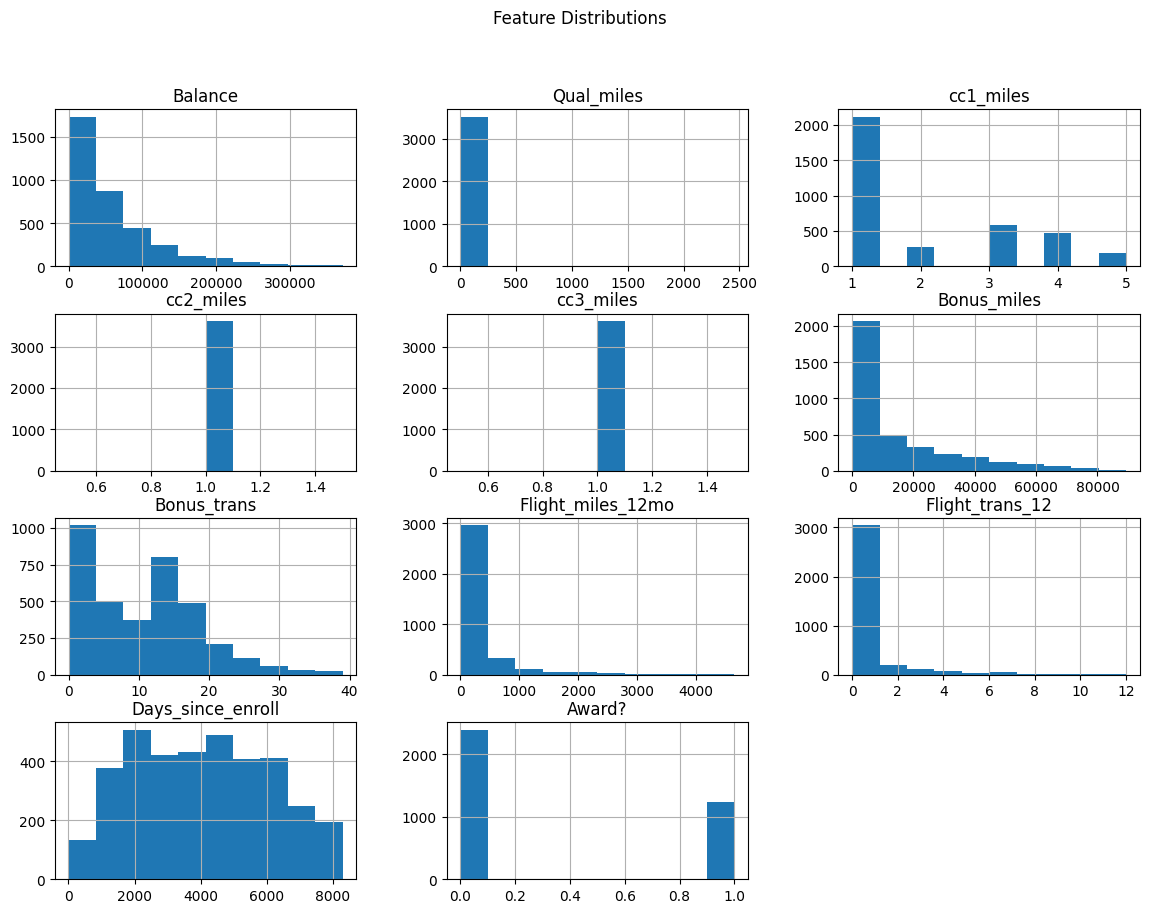

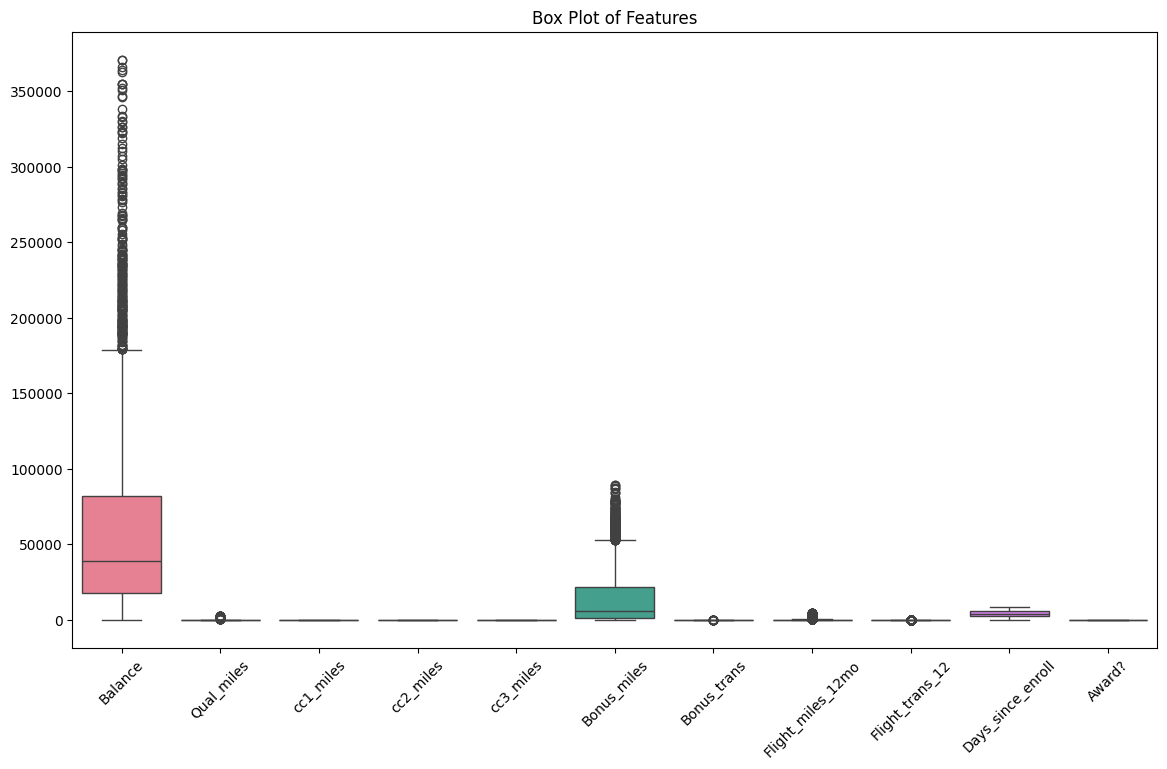

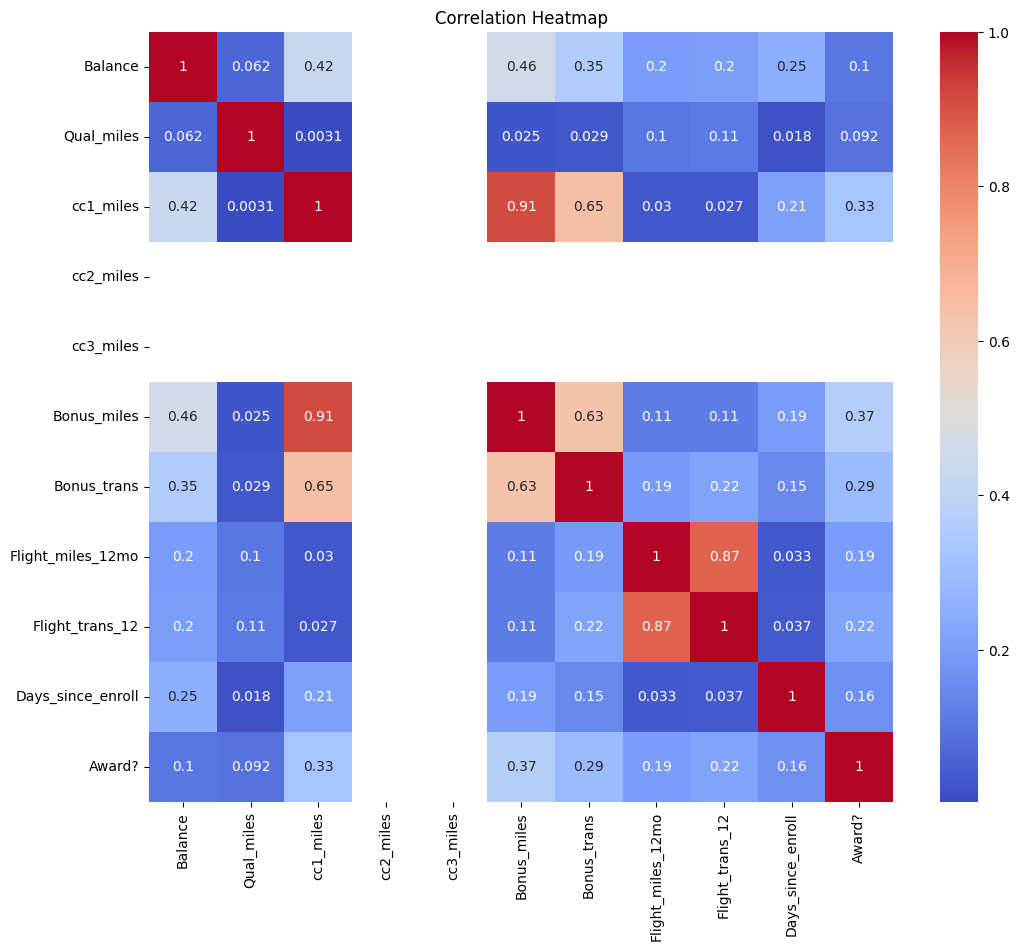

In [8]:
# -----------------------
# Handling Missing values
# -----------------------
print("\nMissing Values:")
print(data.isnull().sum())

# Median imputation for numerical columns
for col in data.columns:
    data[col].fillna(data[col].median())

# -----------------------
# Outlier Detection and Removal (Z-score method)
# -----------------------
z_scores = np.abs(stats.zscore(data))
data_cleaned = data[(z_scores < 3).all(axis=1)]

print("\nDataset shape after outlier removal:")
print(data_cleaned.shape)

# Drop 'ID#' column as it's an identifier and should not be scaled
data_cleaned = data_cleaned.drop('ID#', axis=1)
print("\nDataset shape after dropping 'ID#' column:")
print(data_cleaned.shape)

# -----------------------
# Feature Scaling
# -----------------------
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_cleaned)

# Exploratory Data Analysis (EDA)

# Histograms
data_cleaned.hist(figsize=(14, 10))
plt.suptitle("Feature Distributions")
plt.show()

# Box plots
plt.figure(figsize=(14, 8))
sns.boxplot(data=data_cleaned)
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data_cleaned.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## **Implementing Clustering Algorithms**

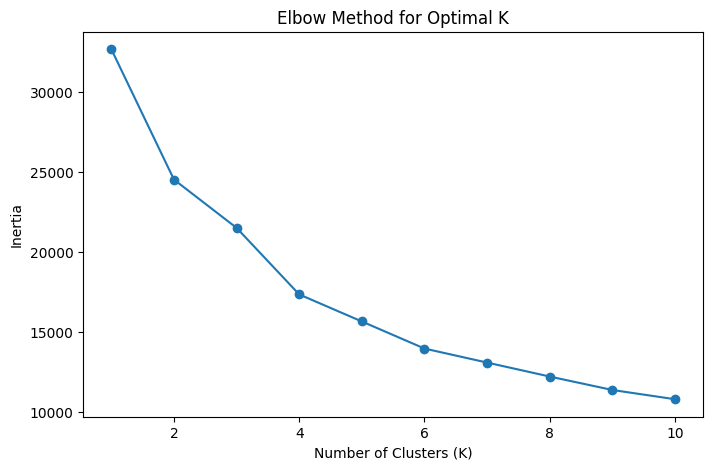


K-Means Silhouette Score:
0.3187208400465597

DBSCAN Silhouette Score:
0.24649228387061523


In [9]:
# ------------------------------------------------------------
# K-Means Clustering
# ------------------------------------------------------------

# -----------------------
# Elbow Method to find Optimal K
# -----------------------
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# Applying K-means Clustering

kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_final.fit_predict(data_scaled)

silhouette_kmeans = silhouette_score(data_scaled, kmeans_labels)

print("\nK-Means Silhouette Score:")
print(silhouette_kmeans)

# Applying DBSCAN Clustering

dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Evaluating DBSCAN Clusters
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    silhouette_dbscan = silhouette_score(
        data_scaled[mask],
        dbscan_labels[mask]
    )
else:
    silhouette_dbscan = "Not Applicable (single cluster or noise)"

print("\nDBSCAN Silhouette Score:")
print(silhouette_dbscan)

## **Visualization**

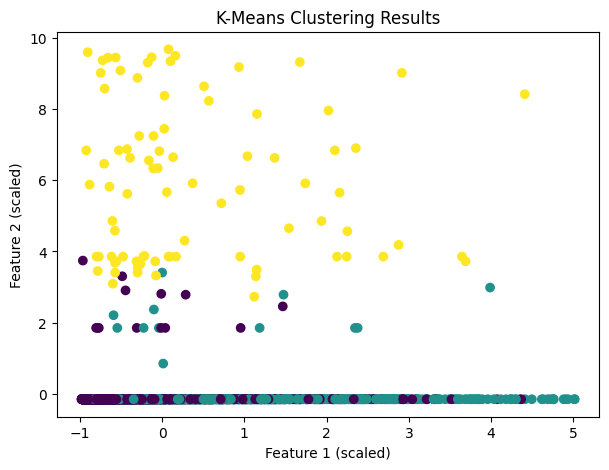

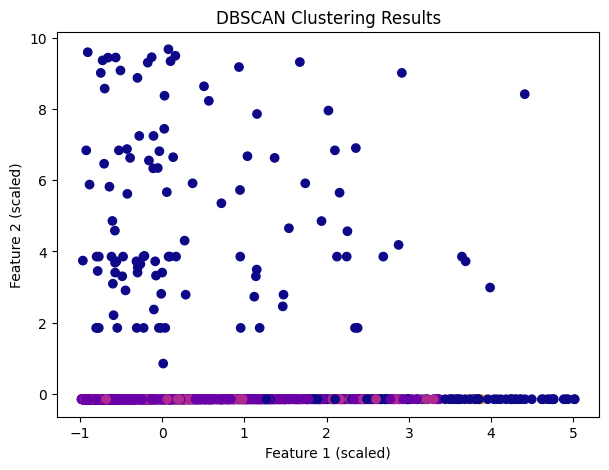

In [10]:
# K-Means visualization
plt.figure(figsize=(7, 5))
plt.scatter(
    data_scaled[:, 0],
    data_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis")
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

# DBSCAN visualization
plt.figure(figsize=(7, 5))
plt.scatter(
    data_scaled[:, 0],
    data_scaled[:, 1],
    c=dbscan_labels,
    cmap="plasma")
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

## Cluster Analysis & Interpretation

In [11]:
data_cleaned = data_cleaned.copy()

data_cleaned.loc[:, "KMeans_Cluster"] = kmeans_labels
data_cleaned.loc[:, "DBSCAN_Cluster"] = dbscan_labels


print("\nK-Means Cluster Profile (Mean Values):")
kmeans_profile = data_cleaned.groupby("KMeans_Cluster").mean()
print(kmeans_profile)
# K-Means Cluster Interpretation:
# Cluster 0: Low-Engagement Customers
# - Characterized by lowest Balance, Qual_miles, Bonus_miles, Bonus_trans, Flight_miles_12mo, and Award?.
# - These are likely new customers or those who rarely engage with the airline's programs.
# Cluster 1: High-Flying & Active Reward Customers
# - Show high values for Bonus_miles, Bonus_trans, Flight_miles_12mo, and Flight_trans_12.
# - Also have a high 'Award?' percentage, indicating frequent redemption of awards.
# - These are likely loyal customers who travel often and actively use their mileage benefits.
# Cluster 2: High-Value Credit Card Holders / Balance Accumulators
# - Distinguished by the highest cc1_miles (indicating higher tier credit card usage) and high Balance.
# - They accumulate significant Bonus_miles but have very low Flight_miles_12mo and Flight_trans_12,
#   suggesting their miles primarily come from credit card spending rather than flying.
# - Moderate Award? percentage, indicating they redeem awards, but perhaps not as frequently as Cluster 1.


print("\nDBSCAN Cluster Profile (Excluding Noise):")
dbscan_profile = data_cleaned[data_cleaned["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster").mean()
print(dbscan_profile)
# DBSCAN Cluster Interpretation:
# Cluster 0: Basic / Non-Awarded Customers
# - Characterized by lower Balance, Bonus_miles, and Bonus_trans compared to Cluster 1.
# - Significantly, they have 'Award?' = 0, meaning they have not redeemed awards.
# - These customers might be less engaged or newer members without award activity.
# Cluster 1: Awarded Customers
# - Generally higher Balance, Bonus_miles, and Bonus_trans.
# - Critically, they have 'Award?' = 1, indicating they have redeemed awards.
# - These customers are actively engaged in the awards program, likely earning and using miles.
# Noise (-1): Outliers
# - Data points classified as noise by DBSCAN do not belong to any dense cluster.
# - These could represent unique customer behaviors that deviate significantly from the main patterns.

print("\nClustering Evaluation Summary:")
print(f"K-Means Silhouette Score : {silhouette_kmeans}")
print(f"DBSCAN Silhouette Score  : {silhouette_dbscan}")


K-Means Cluster Profile (Mean Values):
                     Balance   Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0               37902.452370     3.642003   1.167479        1.0        1.0   
1               98397.764934     5.331265   3.449961        1.0        1.0   
2               86962.392857  1530.952381   2.000000        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0                3804.205140     6.259637         158.869739         0.496677   
1               32523.554694    17.709077         392.823894         1.193173   
2               16631.821429    12.261905         762.202381         2.273810   

                Days_since_enroll    Award?  DBSCAN_Cluster  
KMeans_Cluster                                               
0                     3670.350022  0.18

### DBSCAN Parameter Tuning: Choosing `eps` and `min_samples`

To effectively use DBSCAN, selecting appropriate values for `eps` (epsilon) and `min_samples` is crucial. The `eps` parameter defines the maximum distance between two samples for one to be considered as in the neighborhood of the other. `min_samples` is the number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself.

#### Method for choosing `eps` (Epsilon):

A common approach to determine the optimal `eps` is using the K-distance graph (also known as the elbow method for DBSCAN).

1.  **Calculate the distance to the k-th nearest neighbor** for each point in the dataset. Here, k is typically set to `min_samples`.
2.  **Sort these distances** in ascending order.
3.  **Plot the sorted distances.** The plot will typically show a sharp bend or 'elbow'. The `eps` value can be chosen at this 'elbow' point, where the rate of change of distances is highest. Points after this elbow are likely noise points.

#### Method for choosing `min_samples`:

A general rule of thumb for `min_samples` is to choose a value greater than or equal to the dimensionality of the dataset. For 2-dimensional data, `min_samples` can be 4. For higher-dimensional data, it's often set to `2 * number_of_features` or experimented with values between 4 and 6, or even higher, depending on the dataset density and domain knowledge.

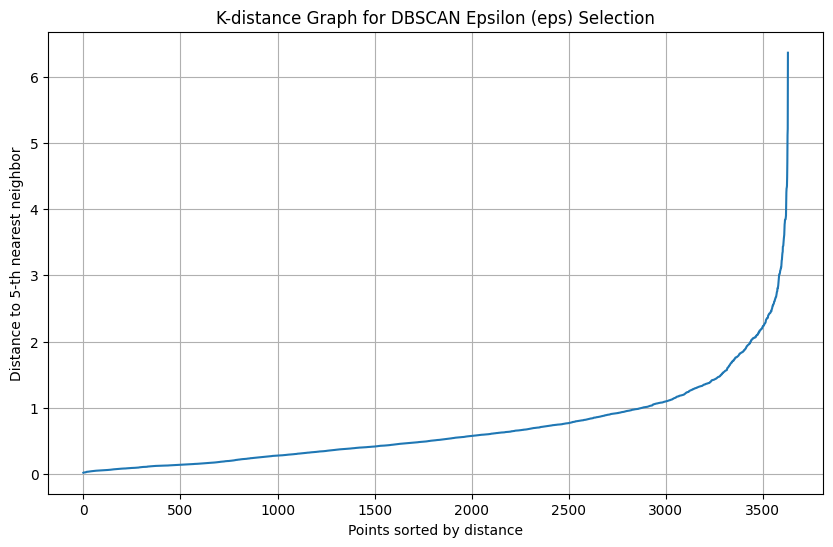


Based on the K-distance graph, look for the 'elbow' point to select an appropriate `eps` value.
For `min_samples`, a value around 5 (or 2 * number_of_features) is often a good starting point for experimentation.


In [12]:
from sklearn.neighbors import NearestNeighbors

# Calculate k-distance for eps selection
# Choose min_samples (k) based on general guidelines or dimensionality
# Let's use min_samples = 2 * number_of_features or a reasonable small number like 5 for demonstration
k = 5 # A common starting point for min_samples

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)

# Sort distances and plot
distances = np.sort(distances[:, k-1], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th nearest neighbor")
plt.title("K-distance Graph for DBSCAN Epsilon (eps) Selection")
plt.grid(True)
plt.show()

print(f"\nBased on the K-distance graph, look for the 'elbow' point to select an appropriate `eps` value.\nFor `min_samples`, a value around {k} (or 2 * number_of_features) is often a good starting point for experimentation.")

### DBSCAN Parameter Tuning

,eps,min_samples,silhouette_score
155,2.9,14,0.637134
126,2.5,9,0.625213
154,2.9,13,0.624993
153,2.9,12,0.624993
139,2.7,10,0.624861



Best DBSCAN Parameters found: eps=2.90, min_samples=14
Best DBSCAN Silhouette Score: 0.6371


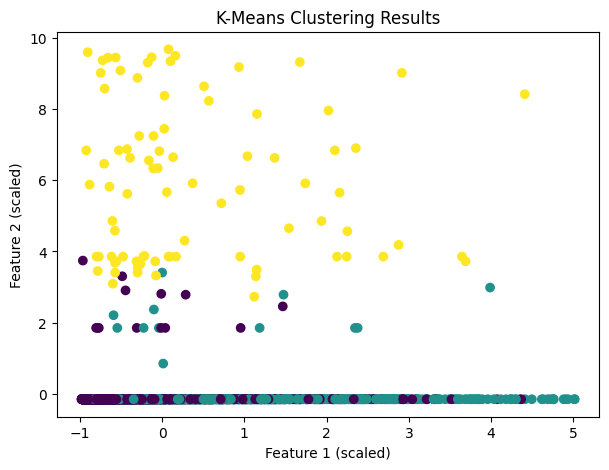

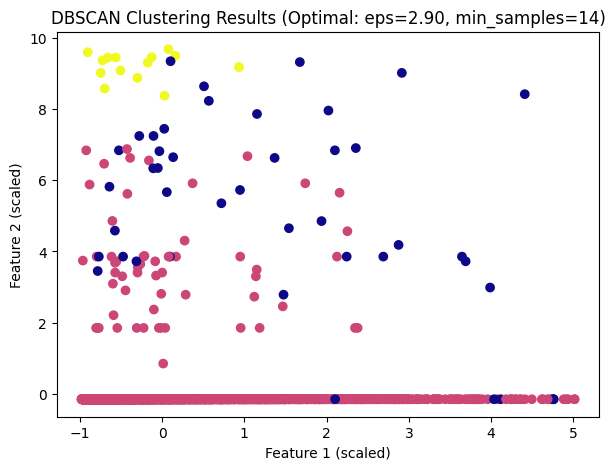

In [14]:
import numpy as np

# Define a range of parameters to test
eps_values = np.arange(0.5, 3.0, 0.2)
min_samples_values = np.arange(3, 15, 1)

best_silhouette_dbscan = -1
best_eps = None
best_min_samples = None

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(data_scaled)

        # Evaluate only if more than one cluster and not all noise
        mask = dbscan_labels != -1
        if len(np.unique(dbscan_labels[mask])) > 1:
            silhouette = silhouette_score(data_scaled[mask], dbscan_labels[mask])
            results.append({'eps': eps, 'min_samples': min_samples, 'silhouette_score': silhouette})

            if silhouette > best_silhouette_dbscan:
                best_silhouette_dbscan = silhouette
                best_eps = eps
                best_min_samples = min_samples
        else:
            results.append({'eps': eps, 'min_samples': min_samples, 'silhouette_score': np.nan}) # Use np.nan instead of string

# Convert results to DataFrame for better viewing
results_df = pd.DataFrame(results)
# Drop rows where silhouette_score is NaN before sorting for display
display(results_df.dropna(subset=['silhouette_score']).sort_values(by='silhouette_score', ascending=False).head())

print(f"\nBest DBSCAN Parameters found: eps={best_eps:.2f}, min_samples={int(best_min_samples)}")
print(f"Best DBSCAN Silhouette Score: {best_silhouette_dbscan:.4f}")

# Apply DBSCAN with the best parameters
dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels_optimal = dbscan_optimal.fit_predict(data_scaled)

# K-Means visualization (re-plotting for comparison with optimal DBSCAN)
plt.figure(figsize=(7, 5))
plt.scatter(
    data_scaled[:, 0],
    data_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis")
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

# DBSCAN visualization with optimal parameters
plt.figure(figsize=(7, 5))
plt.scatter(
    data_scaled[:, 0],
    data_scaled[:, 1],
    c=dbscan_labels_optimal,
    cmap="plasma")
plt.title(f"DBSCAN Clustering Results (Optimal: eps={best_eps:.2f}, min_samples={int(best_min_samples)})")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

After experimenting with various `eps` and `min_samples` values, the optimal parameters for DBSCAN were identified based on the highest silhouette score. This iterative process helps in finding the density-based clusters more effectively.

## **THEORETICAL DISCUSSION**

1.K-Means Clustering:
- Partition-based clustering technique.
- Requires predefined number of clusters (K).
- Minimizes intra-cluster variance.
- Sensitive to outliers and noise.

2.DBSCAN Clustering:
- Density-based clustering technique.
- Does not require predefined number of clusters.
- Identifies noise points explicitly.
- Can find arbitrarily shaped clusters.

3.Key Differences:
- K-Means assumes spherical clusters; DBSCAN does not.
- K-Means is sensitive to outliers; DBSCAN is robust.
- DBSCAN depends on eps and min_samples parameters.

4.Business Interpretation:
- K-Means is suitable for customer segmentation.
- DBSCAN is suitable for anomaly and outlier detection

**CONCLUSION:**

Clustering analysis of the EastWest Airlines dataset reveals
distinct customer segments. K-Means provides structured clusters,
while DBSCAN effectively identifies noise and irregular patterns.
The choice of algorithm depends on business objectives and data
characteristics.